In [3]:
#MLP Paper

import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt #Making features
%matplotlib inline


In [4]:
words = open('names.txt','r').read().splitlines()
words[:8]


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [6]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i , s in enumerate(chars)}
stoi['.']=0
itos ={i:s for s , i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
# train split , dev/validation split , test split
# 80% , 10% , 10%
def build_dataset(words):
    block_size=3
    X , Y =[] , []
    for w in words:
    #print(w)
     context = [0] * block_size
     for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)   
    print(X.shape , Y.shape)
    return X ,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr , Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte , Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [11]:
g = torch.Generator().manual_seed(2147483647)
C=torch.randn((27,2),generator=g)
emb = C[Xtr]
emb.shape

torch.Size([182625, 3, 2])

In [12]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [13]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # -1 show discover what it's !!

In [ ]:
##torch.cat(torch.unbind(emb,1),1).shape emb.view(32,6) == torch.cat(torch.unbind(emb,1),1)

In [14]:
h.shape


torch.Size([182625, 100])

In [15]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)


In [16]:
logits = h@ W2 + b2
logits.shape

torch.Size([182625, 27])

In [17]:
counts = logits.exp()

In [18]:
prob = counts / counts.sum(1,keepdim=True)

In [19]:
prob.shape

torch.Size([182625, 27])

In [20]:
#loss = -prob[torch.arange(32),Y].log().mean()
#loss

In [21]:
Xtr.shape , Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [22]:
#====Woops===#
g = torch.Generator().manual_seed(2147483647)
C=torch.randn((27,10),generator=g)
W1 = torch.randn((30,200),generator=g)
b1 = torch.randn(200,generator=g)
W2 = torch.randn((200,27),generator=g)
b2 = torch.randn(27,generator=g)
parameters = [C,W1,b1,W2,b2]

In [23]:
sum(p.nelement()for p in parameters)

11897

In [24]:
for p in parameters:
    p.requires_grad = True

In [25]:
lre = torch.linspace(-3,1,1000)
lrs = 10**lre


In [26]:
import torch
lri = []
lossi =[]
stepi =[]

for i in range(200000):
    ix = torch.randint(0,Xtr.shape[0],(32,))
     
#FORWARD PASS
    emb = C[Xtr[ix]] # (32,3,2)
    h = torch.tanh(emb.view(-1,30)@W1+b1) #(32,100)
    logits = h @ W2 + b2 # (32,27)
        #counts = logits.exp()
        #prob = counts / counts.sum(1,keepdims =True)
        #loss = -prob[torch.arange(32), Y].log().mean() All comprssed in one line
    loss = F.cross_entropy(logits,Ytr[ix])
    #print(loss.item())

    #Backward
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    #lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad 

    #lri.append(lr)
    lossi.append(loss.log10().item())
    stepi.append(i)


#print(loss.item())

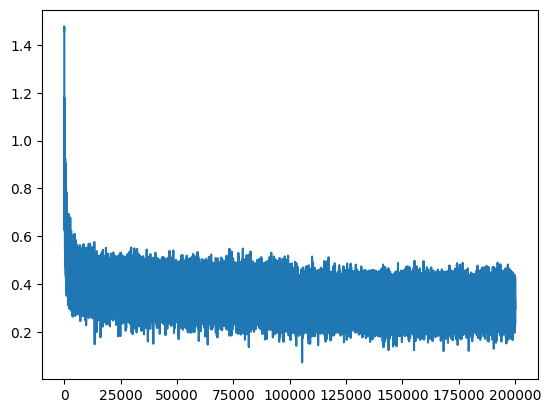

In [27]:
plt.plot(stepi,lossi)

In [28]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 +b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.1672, grad_fn=<NllLossBackward0>)

In [29]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ W1 +b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.1366, grad_fn=<NllLossBackward0>)

In [32]:
# train split , dev/validation split , test split
# 80% , 10% , 10%
def build_dataset(words):
    block_size=3
    X , Y =[] , []
    for w in words:
    #print(w)
     context = [0] * block_size
     for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)   
    print(X.shape , Y.shape)
    return X ,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr , Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte , Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [ ]:
# sample from the model
import torch
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

NameError: name 'block_size' is not defined